# Alpha Zero General for ConnectN/TicTacToe/Connect4

* AlphaZero: [AlphaZero](https://arxiv.org/abs/1712.01815) is a generic game playing program that achieved superhuman performance in Go, Chess and Shogi.
* This notebook provides an implementation of ConnectN and AlphaZero.

## AlphaZero Algorithm

### Neural Network Architecture

The core of AlphaZero is a dual-headed neural network $f_\theta$ with parameters $\theta$ that takes as input the state $s$ of the game board and outputs:

1. A policy vector $\vec{p}_\theta(s)$ representing probabilities over all possible actions
2. A value estimate $v_\theta(s) \in [-1,1]$ of the current position from the perspective of the current player

$$\vec{p}_\theta(s), v_\theta(s) = f_\theta(s)$$

### Monte Carlo Tree Search (MCTS)

For each state-action pair $(s,a)$, we maintain:
- $N(s,a)$: Visit count - number of times action $a$ has been taken from state $s$
- $Q(s,a)$: Action value - expected reward for taking action $a$ from state $s$
- $P(s,a)$: Prior probability - from the neural network's policy output

Each MCTS simulation consists of four phases:

1. **Selection**: Starting from the root node, recursively select the child node with the highest Upper Confidence Bound (UCB) until reaching a leaf node:

   $$U(s,a) = Q(s,a) + c_{\text{puct}} \cdot P(s,a) \cdot \frac{\sqrt{\sum_b N(s,b)}}{1 + N(s,a)}$$

2. **Expansion**: If the leaf node is not terminal and has been visited before, expand it by adding all possible child nodes.

3. **Evaluation**: Instead of random rollouts used in traditional MCTS, AlphaZero evaluates the new leaf node using the neural network:

   $$\vec{p}, v = f_\theta(s_{\text{leaf}})$$

4. **Backup**: Update statistics for all nodes along the visited path:

   - Increment visit counts: $N(s,a) = N(s,a) + 1$
   - Update Q-values: $Q(s,a) = \frac{N(s,a) \cdot Q(s,a) - v}{N(s,a) + 1}$

   Note that we flip the sign of $v$ when moving up the tree to account for alternating players.

### Training Process

After running MCTS simulations (typically 800-1600), we extract an improved policy $\vec{\pi}(s)$ based on the visit counts:

$$\pi(a|s) = \frac{N(s,a)^{1/\tau}}{\sum_b N(s,b)^{1/\tau}}$$

Where $\tau$ is a temperature parameter controlling exploration.

During self-play, for each game state $s_t$, we store:
- Current board state $s_t$
- MCTS-improved policy $\vec{\pi}_t$
- Game outcome $z_t \in \{-1, 1\}$ from the perspective of the current player

The neural network is trained by minimizing:

$$L = \underbrace{(v_\theta(s_t) - z_t)^2}_{\text{value loss}} - \underbrace{\vec{\pi}_t \cdot \log(\vec{p}_\theta(s_t))}_{\text{policy loss}} + \underbrace{c\|\theta\|^2}_{\text{regularization}}$$

### Complete Training Loop

1. **Initialization**: Initialize network parameters $\theta$ randomly
2. **Iteration**: Repeat until convergence:
   1. **Self-play**: Generate games using MCTS guided by the current network
   2. **Training**: Update network parameters by gradient descent on the loss function
   3. **Evaluation**: If the new network wins ≥ 55% against the previous version, replace it

### Key Hyperparameters

- MCTS simulations per move: 800-1600
- Exploration constant $c_{\text{puct}}$: 1-5
- Temperature $\tau$: 1 (early game) → 0 (late game)
- L2 regularization coefficient: 1e-4

## Game: ConnectN

First let's define the ConnectN game. ConnectN is a two-player connection game in which the players first choose a color and then take turns dropping colored discs from the top into a seven-column, six-row vertically suspended grid. The pieces fall straight down, occupying the lowest available space within the column. The objective of the game is to be the first to form a horizontal, vertical, or diagonal line of N discs of your own color.

In [21]:
import numpy as np 
from typing import Tuple, List, Optional, Any

class ConnectN:
    """
    Implementation of an N-in-a-row game (like Connect4, TicTacToe)
    on a wxh board where N pieces in a row wins.
    
    Players alternate placing pieces, trying to get N in a row.
    Player 1 is represented by 1, Player 2 by -1.
    """

    def __init__(self, size: Tuple[int, int] = (3, 3), N: int = 3):
        """
        Initialize a ConnectN game
        
        Args:
            size (tuple): Board dimensions (width, height)
            N (int): Number of pieces in a row needed to win
        """
        super().__init__()
        self.w, self.h = size
        self.size = size
        self.N = N
        self.state = np.zeros(size, dtype=float)
        self.player = 1  # Player 1 starts
        self.last_move = None
        self.score = None

        # Pre-compute win-line directions once
        self.directions = [
            (1, 0),   # horizontal
            (0, 1),   # vertical
            (1, 1),   # diagonal \
            (1, -1)   # diagonal /
        ]
        
    def copy(self):
        """
        Create a copy of this ConnectN game with the same state
        """
        new_game = ConnectN(size=(self.w, self.h), N=self.N)
        new_game.state = self.state.copy()
        new_game.player = self.player
        new_game.last_move = self.last_move
        new_game.score = self.score
        return new_game

    def move(self, action: Tuple[int, int]) -> bool:
        """
        Make a move on the board
        
        Args:
            action (tuple): (x, y) coordinates of the move
            
        Returns:
            bool: True if the move was valid and made, False otherwise
        """
        if self.score is not None:
            return False
        
        x, y = action

        if not (0 <= x < self.w and 0 <= y < self.h):
            return False
        if self.state[x, y] != 0:
            return False
        self.state[x, y] = self.player
        self.last_move = (x, y)

        # Check if the last move was a winning move
        if self._check_win((x, y)):
            self.score = self.player
        elif np.all(self.state != 0):
            self.score = 0
        
        self.player *= -1  # Switch players
        return True

    def available_moves(self) -> List[Tuple[int, int]]:
        """
        Get a list of all available moves on the board
        
        Returns:
            List of (x, y) coordinates representing legal moves
        """
        if self.score is not None:
            return []
        
        empty = np.where(self.state == 0)
        return list(zip(empty[0], empty[1]))

    def available_mask(self) -> np.ndarray:
        """
        Get a binary mask of available moves on the board
        
        Returns:
            np.ndarray: 2D array with 1s at available move locations
        """
        return (self.state == 0).astype(np.bool)
    
    def get_state_representation(self) -> np.array:
        """
        Get canonical form of the state from current player's perspective
        
        Returns:
            np.ndarray: State representation with current player always as 1
        """
        return self.state * self.player

    def is_game_over(self) -> bool:
        """
        Check if the game is over
        
        Returns:
            bool: True if the game is over, False otherwise
        """
        return self.score is not None
    
    def get_winning_loc(self) -> np.array:
        """
        Get the coordinates of the winning line for rendering
        
        Returns:
            np.ndarray: Array of coordinates forming the winning line
        """
        if self.score not in [-1, 1] or self.last_move is None:
            return np.array([])
        
        x, y = self.last_move
        player = self.score

        for dx, dy in self.directions:
            coords = self._check_line(x, y, dx, dy, player)
        
            if len(coords) >= self.N:
                return np.array(coords)
                
        return np.array([])

    def _check_win(self, loc: Tuple[int, int]) -> bool:
        """
        Check if the last move was a winning move

        Args:
            loc (Tuple[int, int]): Last move as (x, y) tuple

        Returns:
            bool: True if the last move was a winning move
        """
        if self.score is not None:
            return True
        
        x, y = loc
        player = self.state[x, y]

        for dx, dy in self.directions:
            coords = self._check_line(x, y, dx, dy, player)
        
            if len(coords) >= self.N:
                return True
        
        return False

    def _check_line(self, x: int, y: int, dx: int, dy: int, player: int) -> List[Tuple[int, int]]:
        """
        Collect coordinates in a specific direction
    
        Args:
            x, y: Starting coordinates
            dx, dy: Direction vector
            player: Player value to match
        
        Returns:
            List of coordinates of consecutive matching pieces
        """
        coords = [(x, y)]  # Start with the initial position
    
        # Check in the positive direction
        for i in range(1, self.N):
            nx, ny = x + i*dx, y + i*dy
            if (0 <= nx < self.w and 0 <= ny < self.h and 
                self.state[nx, ny] == player):
                coords.append((nx, ny))
            else:
                break
            
        # Check in the negative direction
        for i in range(1, self.N):
            nx, ny = x - i*dx, y - i*dy
            if (0 <= nx < self.w and 0 <= ny < self.h and 
                self.state[nx, ny] == player):
                coords.append((nx, ny))
            else:
                break
            
        return coords


# game = ConnectN(size=(3, 3), N=3)
# game.move((0, 0))
# game.move((1, 0))
# game.move((0, 1))
# game.move((1, 1))
# game.move((0, 2))
# print(game.state)
# print(game.get_winning_loc())
# print(game.score)
# print(game.available_moves())

In [22]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

import numpy as np
import time

from copy import copy


class Play:
    def __init__(self, game, player1=None, player2=None):
        """
        Simple game visualizer for board games
        
        Args:
            game: The game object with state and move logic
            player1: AI function for player 1 (or None for human)
            player2: AI function for player 2 (or None for human)
        """
        self.original_game = game
        self.game = copy(game)
        self.player1 = player1
        self.player2 = player2
        self.end = False
        
        # Create the visualization
        self.setup_display()
        
        if self.player1 is not None and self.player2 is not None:
            self.setup_ai_vs_ai_game()
        else:
            # Make first AI move if applicable
            if self.player1 is not None and self.game.player == 1:
                self.make_ai_move(self.player1)
            
            # Connect click handler
            self.fig.canvas.mpl_connect('button_press_event', self.handle_click)
        
        self.fig.canvas.draw()
        plt.pause(0.1)
        
    def setup_display(self):
        """Set up the game display"""
        plt.close('all')
        
        # Create figure with appropriate size
        w, h = self.game.size
        figsize = (w/1.6, h/1.6) if w*h < 25 else (w/2.1, h/2.1)
        self.fig = plt.figure("Game", figsize=figsize)
        self.fig.subplots_adjust(0.1, 0.1, 1, 1)
        
        # Set up the axes
        self.ax = self.fig.gca()
        self.ax.grid()
        self.ax.format_coord = lambda x, y: ''  # Remove coordinate tooltips
        self.ax.set_xlim([-.5, w-.5])
        self.ax.set_ylim([-.5, h-.5])
        self.ax.set_xticks(np.arange(0, w, 1))
        self.ax.set_yticks(np.arange(0, h, 1))
        self.ax.set_aspect('equal')
        
        # Hide spines
        for loc in ['top', 'right', 'bottom', 'left']:
            self.ax.spines[loc].set_visible(False)
            
        # Show the figure
        plt.ion()  # Enable interactive mode
        self.fig.canvas.draw()
    
    def setup_ai_vs_ai_game(self):
        """Set up and start an automated game between two AI players"""
        # Create animation that will advance the game each frame
        self.anim = FuncAnimation(
            self.fig, 
            self.advance_ai_game, 
            frames=None,  # Run indefinitely until game ends
            interval=500,  # Convert to milliseconds
            repeat=False,
            cache_frame_data=False
        )
    
    def advance_ai_game(self, frame):
        """Advance the game by one AI move"""
        if self.end:
            self.anim.event_source.stop()  # Stop animation when game ends
            return
        
        # Determine current AI player
        current_ai = self.player1 if self.game.player == 1 else self.player2
        
        # Make the move
        succeed = False
        while not succeed:
            loc = current_ai(self.game)
            succeed = self.game.move(loc)
        
        # Draw updated state
        self.draw_current_state()
    
    def make_ai_move(self, ai_player):
        """Make a move using the AI player"""
        succeed = False
        while not succeed:
            loc = ai_player(self.game)
            succeed = self.game.move(loc)
        self.draw_current_state()
    
    def draw_current_state(self):
        """Draw the current game state"""
        if self.end:
            return
            
        # Draw the last move
        i, j = self.game.last_move
        c = 'salmon' if self.game.state[i, j] == 1 else 'lightskyblue'
        self.ax.scatter(i, j, s=500, marker='o', zorder=3, c=c)
        
        # Draw winner if game is over
        score = self.game.score
        if score is not None:
            if score in [-1, 1]:
                locs = self.game.get_winning_loc()
                c = 'darkred' if score == 1 else 'darkblue'
                self.ax.scatter(locs[:,0], locs[:,1], s=300, marker='*', c=c, zorder=4)
            self.end = True
            
        self.fig.canvas.draw()
    
    def handle_click(self, event):
        """Handle mouse click events"""
        if self.end or event.xdata is None or event.ydata is None:
            return
            
        # Get integer coordinates from click
        loc = (int(round(event.xdata)), int(round(event.ydata)))
        
        # Try to make the move
        succeed = self.game.move(loc)
        if succeed:
            self.draw_current_state()
            
            # Handle AI's turn if game isn't over
            if not self.end:
                current_player = self.player1 if self.game.player == 1 else self.player2
                if current_player is not None:
                    self.make_ai_move(current_player)

# Example usage:
# %matplotlib widget

# gameplay = Play(
#     ConnectN(size=(6, 6), N=4),
#     player1=None,
#     player2=None
# )

## Monte Carlo Tree Search (MCTS)

Next, we implement the Monte Carlo Tree Search algorithm. The MCTS algorithm is used to select the best move to play by simulating games and updating the statistics of each move.

In [47]:
import numpy as np  
import torch
import math 
import random
from copy import deepcopy
from typing import Tuple, List, Optional, Any, Dict

C_PUCT = 1.0  # Exploration constant for MCTS

# Define transformations and their inverses to speed up MCTS
# Each tuple contains (transform_function, inverse_transform_function)
transformations = [
    # t0: Identity (no change)
    (lambda x: x, lambda x: x),
    
    # t1: Horizontal flip
    (lambda x: np.fliplr(x), lambda x: np.fliplr(x)),
    
    # t2: Vertical flip
    (lambda x: np.flipud(x), lambda x: np.flipud(x)),
    
    # t3: 180° rotation (horizontal + vertical flip)
    (lambda x: np.flipud(np.fliplr(x)), lambda x: np.flipud(np.fliplr(x))),
    
    # t4: Transpose (diagonal reflection)
    (lambda x: x.T, lambda x: x.T),
    
    # t5: 90° clockwise rotation
    (lambda x: np.transpose(np.fliplr(x)), lambda x: np.flipud(np.transpose(x))),
    
    # t6: 90° counterclockwise rotation
    (lambda x: np.transpose(np.flipud(x)), lambda x: np.fliplr(np.transpose(x))),
    
    # t7: Transpose with 180° rotation
    (lambda x: np.transpose(np.flipud(np.fliplr(x))), 
     lambda x: np.flipud(np.fliplr(np.transpose(x))))
]

# Subset for non-square boards (only flips, no rotations or transposes)
transformations_half = transformations[:4]

class MCTSNode:
    """
    Monte Carlo Tree Search Node with neural network value function (AlphaZero style)
    Each node represents game state, keeps track of Q, U, N values for selecting actions
    """

    def __init__(self, game, parent=None, prior_probability=0.0, move=None):
        """
        Initialize a new MCTS node with given game state

        Args:
            game: The game state of this node
            parent: The parent node of this node or None if root node
            prior_probability: Prior probability from policy network (p_a)
            move: The move that led to this node from the parent
        """
        self.game = game 
        self.parent = parent
        self.children: Dict[Any, MCTSNode] = {} #map from move to child node
        self.move = move 

        # Statistics
        self.N = 0 # Number of visits (N)
        self.V = 0 # Sum of values from children (W)
        self.prior_p = prior_probability   # Prior probability from policy (P)

        # Game Result
        self.is_expanded = False
        self.outcome = None  # Game outcome from this node (if terminal)
        
        if game.score is not None:
            self.outcome = game.score
    
    def is_leaf(self) -> bool:
        """
        Check if this node is a leaf (i.e. no children)
        """
        return len(self.children) == 0
    
    def get_value(self) -> float:
        """
        Get the current Q value for this node

        Returns:
            float: The average value W/N or 0 if N is 0
        """
        if self.N == 0:
            return 0.0
        
        return self.V / self.N

    def select_child(self) -> 'MCTSNode':
        """
        Select a child node using the upper confidence bound formula

        Returns:
            MCTSNode: The child node with the highest U value
        """
        best_score = -math.inf
        best_child = None

        # Total visit count for parent node
        parent_N_sqrt = math.sqrt(self.N)

        for child in self.children.values():
            # UCB = Q + U
            # where U is proportional to P *sqrt(parent_N) / (1 + child_N)
            U = C_PUCT * child.prior_p * parent_N_sqrt / (1 + child.N)
            Q = -child.get_value()
            score = Q + U

            if score > best_score:
                best_score = score
                best_child = child
        
        return best_child
    
    def get_policy_with_symmetry(self, policy_network, state, valid_moves):
        """
        Get policy and value using symmetry transformations.
        
        For square boards, randomly apply one of 8 transformations to the input state,
        then apply the inverse transformation to the policy output.
        
        Args:
            policy_network: Neural network that outputs policy and value
            state: Current game state
            valid_moves: List of valid moves
            
        Returns:
            Tuple of (policy, value)
        """
        # Determine which transformation set to use based on board dimensions
        w, h = self.game.size
        is_square = w == h
        trans_set = transformations if is_square else transformations_half
        # Randomly select a transformation
        # t, t_inv = random.choice(trans_set)
        
        # Apply transformation to state (keep player perspective) and ensure positive strides
        # transformed_state = t(state).copy()
        # transformed_state_tensor = torch.tensor(transformed_state, dtype=torch.float).unsqueeze(0).unsqueeze(0) # Add batch and channel dims
        # Convert state to tensor without transformations
        state_tensor = torch.tensor(state, dtype=torch.float).unsqueeze(0).unsqueeze(0) # Add batch and channel dims
        

        # Get policy and value from the network using transformed state
        with torch.no_grad():
            policy_output, value = policy_network(state_tensor) # Forward pass ((1, 1, w, h) -> (1, w, h), (1))

        policy = policy_output.squeeze().numpy().reshape(self.game.size) # (1, w, h) -> (w, h)
        value = value.item()

        # Apply inverse transformation to policy
        # policy = t_inv(policy).copy()
        
        # # Create a mask for valid moves
        mask = np.zeros(self.game.size, dtype=bool)
        for move in valid_moves:
            mask[move] = True
            
        # Apply mask and renormalize
        policy = policy * mask
        if policy.sum() > 0:
            policy /= policy.sum()
            
        return policy, value

    
    def expand(self, policy_network):
        """
        Expand the node by adding all possible child states
        
        Args:
            policy_network: Neural network that outputs policy and value
        """

        # terminal or fully expanded
        if self.is_expanded or self.outcome is not None:
            return
        
        valid_moves = self.game.available_moves()

        if not valid_moves:
            self.outcome = self.game.score
            return
        
        state = self.game.get_state_representation()
        
        # Get policy and value using symmetry
        policy, value = self.get_policy_with_symmetry(policy_network, state, valid_moves)

        # Create children for all valid moves 
        for move in valid_moves:
            child_game = self.game.copy()
            child_game.move(move)

            # Get prior probability for this move from the masked policy
            prior_p = policy[move[0], move[1]]
            
            # Create child node
            self.children[move] = MCTSNode(child_game, 
                                           parent=self, 
                                           prior_probability=prior_p, 
                                           move=move)
        
        self.is_expanded = True

        # Return the value estimate for the current node
        return value

    def backup(self, value: float):
        """
        Update the node statistics by backpropagating the value

        Args:
            value (float): The value to propagate up the tree
        """
        node = self

        while node is not None:
            node.N += 1
            node.V += value 
            value = -value  # Switch value sign for opponent
            node = node.parent
    
    def search(self, policy_network, num_simulations: int = 800) -> Dict[Tuple[int,int], float]:
        """
        Perform MCTS search from this node

        Args:
            policy_network: Neural network that outputs policy and value
            num_simulations: Number of simulations to run

        Returns:
            Dict: Map from move to visit probability
        """
        for _ in range(num_simulations):
            # Phase 1: Selection - find a leaf node by following UCB
            leaf = self
            while leaf.is_expanded and not leaf.is_leaf():
                leaf = leaf.select_child()

            # Don't expand if the game is over
            if leaf.outcome is not None:
                # Game is over, use the known outcome 
                leaf.backup(leaf.outcome * leaf.game.player)
                continue
            
            # Phase 2: Expansion - add children and evaluate the node
            value = leaf.expand(policy_network)

            # Phase 3: Backup - propagate the value back to the root
            leaf.backup(value)

        # Calculate improved policy based on visit counts
        improved_policy = {}
        N_total = sum(child.N for child in self.children.values())

        for move, child in self.children.items():
            improved_policy[move] = child.N / N_total
        
        return improved_policy
    
    def get_best_move(self, temperature: float = 1.0) -> Tuple[Any, Dict]:
        """
        Select a move based on visit counts

        Args:
            temperature: Controls exploration vs exploitation
                temperature -> 0: Choose most visited node
                temperature = 1: Sample proportional to visit count
                temperature -> ∞: Uniform random selection
        Returns:
            Tuple: (selected move, {move: probability} dictionary)
        """
        if not self.is_expanded:
            raise ValueError("Cannot select from unexpanded node")
            
        if not self.children:
            raise ValueError("Node has no children to select from")
        
        moves = list(self.children.keys())
        visit_counts = np.array([self.children[move].N for move in moves])

        if temperature == 0:
            # Greedy selection
            selected_idx = np.argmax(visit_counts)
            selected_move = moves[selected_idx]
            probs = np.zeros_like(visit_counts, dtype=float)
            probs[selected_idx] = 1.0
        else:
            # Apply temperature to visit counts
            if temperature != 1.0:
                visit_counts = np.power(visit_counts, 1.0 / temperature)
            
            # Normalize probabilities
            probs = visit_counts / np.sum(visit_counts)

            # Sample from the distribution
            selected_idx = np.random.choice(len(moves), p=probs)
            selected_move = moves[selected_idx]
        
        # Return the selected move and the probability distribution
        return selected_move, {move: prob for move, prob in zip(moves, probs)}

    def detach_from_parent(self):
        """
        Remove the parent reference to prevent cycles
        """
        if self.parent:
            if self.move in self.parent.children:
                del self.parent.children[self.move]
            self.parent = None
    
    def add_dirichlet_noise(self, alpha=0.3, epsilon=0.25):
        """
        Add Dirichlet noise to the prior probabilities of root's children to encourage exploration.
        
        Args:
            alpha: Concentration parameter for Dirichlet distribution. Lower values mean more concentration
                  on fewer actions (more peaky distribution).
            epsilon: Weight of noise to add (0.25 = 25% noise, 75% prior probabilities)
        """
        if not self.children:
            return
            
        moves = list(self.children.keys())
        noise = np.random.dirichlet([alpha] * len(moves))
        
        for i, move in enumerate(moves):
            child = self.children[move]
            child.prior_p = (1 - epsilon) * child.prior_p + epsilon * noise[i]

### Neural Network Architecture

AlphaZero uses a neural network to predict the policy and value of a given game state. The neural network architecture consists of:
- Input layer: Game state representation
- Convolutional layers: Extract features from the game state
- Residual tower: Multiple residual blocks to capture complex patterns
- Policy head: Output layer for policy prediction
- Value head: Output layer for value prediction

<img src="../../assets/images/AlphaZero-Arch.png" width="auto">
<img src="../../assets/images/AlphaZero-Arch2.png" width="400">

In [48]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np 
from typing import Tuple, List


class ResBlock(nn.Module):
    """
    Residual block for AlphaZero neural network
    Each block contains two convolutional layers with batch normalization
    and a residual connection.
    """

    def __init__(self, channels: int, kernel_size: int = 3):
        """
        Initialize a new residual block

        Args:
            channels: Number of input and output channels
            kernel_size: Size of the convolutional kernel, default 3
        """
        super(ResBlock, self).__init__()

        self.conv1 = nn.Conv2d(channels, channels, kernel_size, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(channels)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """ Forward pass through the residual block """
        residual = x
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)) + residual)
        return x

class AlphaZeroPolicy(nn.Module):
    """
    Neural network for AlphaZero that predicts policy and value

    The network takes a board state and outputs:
    1. A policy distribution over possible moves
    2. A value estimation for the current position
    """

    def __init__(self, board_size: Tuple[int, int], num_res_blocks: int = 4, 
                 num_channels: int = 32):
        """
        Initialize a new AlphaZero neural network

        Args:
            board_size: (width, height) of the game board
            num_res_blocks: Number of residual blocks in the network
            num_channels: Number of channels in convolutional layers
        """
        super(AlphaZeroPolicy, self).__init__()

        self.board_size = board_size
        self.num_res_blocks = num_res_blocks
        self.num_channels = num_channels
        w, h = board_size
        self.action_size = w * h # Total number of possible actions

        # Initial convolutional layer
        self.input_layer = nn.Sequential(
            nn.Conv2d(1, num_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(num_channels),
            nn.ReLU()
        )
        # outputs num_channels x w x h because 3x3 kernel with padding 1 doesn't change size (w - 3 + 2)/1 + 1 = w

        # Backbone with residual blocks
        self.res_blocks = nn.ModuleList([
            ResBlock(num_channels) for _ in range(num_res_blocks)
        ])

        self.policy_head = nn.Sequential(
            nn.Conv2d(num_channels, 32, kernel_size=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(32 * w * h, self.action_size)
        )

        self.value_head = nn.Sequential(
            nn.Conv2d(num_channels, 32, kernel_size=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(32 * w * h, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Tanh()
        )
    
    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Forward pass through the network
        
        Args:
            x: Input tensor representing the board state, shape (batch_size, 1, width, height)
            
        Returns:
            Tuple of (policy, value):
                policy: Policy logits, shape (batch_size, width, height)
                value: Value estimate, shape (batch_size, 1)
        """
        # Input layer 
        x = self.input_layer(x)

        # Residual blocks
        for block in self.res_blocks:
            x = block(x)
        
        #Policy head
        policy = self.policy_head(x)
        policy = F.softmax(policy, dim=1) # apply softmax over the board
        policy = policy.view(-1, *self.board_size) # reshape to board_size

        # Value head
        value = self.value_head(x) # single value between -1 and 1

        return policy, value
    
    def get_move_probs(self, state: np.ndarray, valid_moves: list = None) -> Tuple[np.ndarray, float]:
        """
        Get move probabilities and value estimate for a game state
        
        Args:
            state: The game state as a numpy array
            valid_moves: List of valid moves to mask the policy output
            
        Returns:
            Tuple of (move_probs, value):
                move_probs: Probability distribution over moves
                value: Value estimate
        """
        # Convert state to tensor and add batch and channel dimensions
        x = torch.FloatTensor(state).unsqueeze(0).unsqueeze(0)
        
        with torch.no_grad():
            policy, value = self.forward(x)
        
        # Convert to numpy
        policy = policy.squeeze().numpy()
        value = value.item()
        
        # Mask invalid moves if provided
        if valid_moves is not None:
            # Create a mask of zeros
            mask = np.zeros(self.board_size, dtype=np.bool_)
            
            # Set valid moves to 1
            for move in valid_moves:
                mask[move] = True
            
            # Apply mask - set probability of invalid moves to 0
            policy = policy * mask
            
            # Re-normalize
            if policy.sum() > 0:
                policy /= policy.sum()
        
        return policy, value


### Train AlphaZero

Finally, we train the AlphaZero agent to play ConnectN. The training process consists of:
1. Self-play data generation
2. Neural network training
3. Evaluation against previous versions

In [ ]:
import numpy as np
import torch
import torch.nn.functional as F
import torch.optim as optim
import os
import matplotlib.pyplot as plt
import random

from typing import List, Dict, Tuple, Optional
from tqdm import tqdm
from collections import deque

class AlphaZeroTrainer:
    """
    AlphaZero trainer that handles:
    1. Self-play data generation
    2. Neural network training
    3. Evaluation against previous versions
    """
    def __init__(self, game_class, game_args: Dict = None, 
                 policy_model: AlphaZeroPolicy = None,
                 lr: float = 0.005, weight_decay: float = 1e-4, 
                 batch_size: int = 64, mcts_sims: int = 1000,
                 buffer_size: int = 10000, checkpoint_dir: str = 'models'):
        """
        Initialize the AlphaZero trainer
        
        Args:
            game_class: Game class (e.g., ConnectN)
            game_args: Arguments for game initialization
            policy_model: Policy model to train
            lr: Learning rate for optimizer
            weight_decay: Weight decay for optimizer
            batch_size: Batch size for training
            mcts_sims: Number of MCTS simulations per move
            buffer_size: Maximum size of replay buffer
            checkpoint_dir: Directory to save model checkpoints
        """
        
        # Game and model initialization
        self.game_class = game_class
        self.game_args = game_args or {}
        self.game = game_class(**self.game_args)

        self.model = policy_model

        # Optimizer
        self.optimizer = optim.Adam(
            self.model.parameters(), 
            lr=lr, 
            weight_decay=weight_decay
        )

        # Training parameters
        self.batch_size = batch_size
        self.mcts_sims = mcts_sims
        self.buffer_size = buffer_size

        # Experience replay buffer
        self.replay_buffer = deque(maxlen=buffer_size)
        
        # Checkpointing
        self.checkpoint_dir = checkpoint_dir
        os.makedirs(checkpoint_dir, exist_ok=True)
        
        # Statistics
        self.train_losses = []
        self.policy_losses = []
        self.value_losses = []
        self.game_lengths = []
    
    def self_play(self, num_games: int = 100, temperature: float = 1.0,
                 temp_threshold: int = 10) -> List[Dict]:
        """
        Play games against itself to generate training data
        
        Args:
            num_games: Number of self-play games
            temperature: Temperature for move selection
            temp_threshold: Move number after which temperature is set to ~0
            # Add dirichlet noise for exploration in the root node of MCTS for more complex games
        Returns:
            List of game examples
        """
        examples = []
        game_results = {"wins_p1": 0, "wins_p2": 0, "draws": 0}

        for _ in tqdm(range(num_games), desc="Self-play games"):
            game = self.game_class(**self.game_args)
            game_history = []
            move_count = 0

            while not game.is_game_over():
                root = MCTSNode(game.copy())

                # Conduct MCTS search to get improved policy
                root.search(self.model, self.mcts_sims)

                # Get improved policy based on visit counts
                moves = list(root.children.keys())
                visit_counts = np.array([root.children[m].N for m in moves])

                # Use temperature parameter to control exploration
                t = temperature if move_count < temp_threshold else 0.1

                if t <= 0.1:
                    # Almost deterministic - choose best move
                    best_idx = np.argmax(visit_counts)
                    probs = np.zeros_like(visit_counts)
                    probs[best_idx] = 1.0
                else:
                    # Apply temperature
                    counts_t = visit_counts ** (1/t)
                    probs = counts_t / np.sum(counts_t)
                
                # Convert to full board size probabilities
                board_probs = np.zeros(game.size)
                for move, prob in zip(moves, probs):
                    board_probs[move] = prob
                
                # Store state, policy, value (value will be updated after game ends)
                game_history.append({
                    'state': game.get_state_representation(),
                    'policy': board_probs,
                    'player': game.player
                })
                
                # Sample and make a move
                move_idx = np.random.choice(len(moves), p=probs)
                move = moves[move_idx]
                game.move(move)
                move_count += 1

            # Game is over - get final outcome
            outcome = game.score

             # Track game results
            if outcome == 1:
                game_results["wins_p1"] += 1
            elif outcome == -1:
                game_results["wins_p2"] += 1
            else:
                game_results["draws"] += 1

            # Update values in game history based on outcome
            for example in game_history:
                # Convert outcome to example's player perspective
                example['value'] = outcome * example['player']
                del example['player']  # Remove player key
                examples.append(example) # Add to training examples

            # Track game length
            self.game_lengths.append(move_count)

        # Print summary of self-play results
        print(f"\nSelf-play summary: {game_results['wins_p1']} X wins, {game_results['wins_p2']} O wins, {game_results['draws']} draws")
        print(f"Average game length: {sum(self.game_lengths[-num_games:]) / num_games:.1f} moves")

        self.replay_buffer.extend(examples)

        # if buffer is too large - keep most recent examples
        if len(self.replay_buffer) > self.buffer_size:
            self.replay_buffer = deque(list(self.replay_buffer)[-self.buffer_size:], 
                                      maxlen=self.buffer_size)

        return examples
    
    def train(self, epochs: int = 1, sample_size: int = 2048):
        """
        Train the policy network using examples from the replay buffer
        
        Args:
            epochs: Number of training epochs
            sample_size: Number of examples to sample for each epoch
        """
        if len(self.replay_buffer) < self.batch_size:
            print(f"Buffer only has {len(self.replay_buffer)} examples. Need at least {self.batch_size}.")
            return
        
        sample_size = min(sample_size, len(self.replay_buffer))
        
        if sample_size == 0:
            print("No examples in replay buffer. Skipping training.")
            return

        # Sample from replay buffer
        samples = np.random.choice(list(self.replay_buffer), sample_size, replace=False) 
        
        # Convert lists to numpy arrays first, then to tensors
        states_np = np.array([s['state'] for s in samples])
        policies_np = np.array([s['policy'].flatten() for s in samples])
        values_np = np.array([s['value'] for s in samples])
        
        # Convert numpy arrays to tensors
        states = torch.tensor(states_np, dtype=torch.float).unsqueeze(1)
        policies = torch.tensor(policies_np, dtype=torch.float)
        values = torch.tensor(values_np, dtype=torch.float).unsqueeze(1)

        # Create dataset and dataloader
        dataset = torch.utils.data.TensorDataset(states, policies, values)
        dataloader = torch.utils.data.DataLoader(dataset, batch_size=self.batch_size, shuffle=True)

        iteration_total_loss = 0
        iteration_policy_loss = 0
        iteration_value_loss = 0

        # Training loop
        self.model.train()
        for epoch in range(epochs):
            losses = {'total': 0, 'policy': 0, 'value': 0}
        
            for states, target_policies, target_values in dataloader:
                # Forward pass
                policy_logits, values = self.model(states)
                policy_logits = policy_logits.view(policy_logits.size(0), -1)
            
                # Calculate losses
                policy_loss = -torch.mean(torch.sum(target_policies * torch.log(policy_logits + 1e-8), dim=1))
                value_loss = F.mse_loss(values, target_values)
                loss = policy_loss + value_loss
            
                # Backward pass and optimization
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()
            
                # Track batch losses (weighted by batch size)
                batch_size = states.size(0)
                losses['total'] += loss.item() * batch_size
                losses['policy'] += policy_loss.item() * batch_size
                losses['value'] += value_loss.item() * batch_size

            # Calculate average losses
            for key in losses:
                losses[key] /= len(dataset)
        
            # Log and store results
            print(f"Epoch {epoch+1}/{epochs}, "
                f"Loss: {losses['total']:.4f}, "
                f"Policy Loss: {losses['policy']:.4f}, "
                f"Value Loss: {losses['value']:.4f}")
            
            iteration_total_loss += losses['total']
            iteration_policy_loss += losses['policy']
            iteration_value_loss += losses['value']

        
        self.train_losses.append(iteration_total_loss / epochs)
        self.policy_losses.append(iteration_policy_loss / epochs)
        self.value_losses.append(iteration_value_loss / epochs)
    
    def run(self, iterations=5, self_play_games=100, training_epochs=1, sample_size=2048, eval_games=10):
        """
        Run the full training loop for multiple iterations
        
        Args:
            iterations: Number of training iterations
            self_play_games: Number of self-play games per iteration
            sample_size: Number of examples to sample for training
            training_epochs: Number of training epochs per iteration
            eval_games: Number of evaluation games against previous model
        """
        for iteration in range(iterations):
            print(f"\n===== Iteration {iteration+1}/{iterations} =====")
            
            # 1. Self-play to generate data
            print("Generating self-play games...")
            self.self_play(num_games=self_play_games)
            
            # 2. Train on collected data
            print("\nTraining model...")
            self.train(epochs=training_epochs, sample_size=sample_size)

            # 3. Evaluate model
            # print("\nEvaluating model...")
            # self.evaluate(num_games=eval_games)
            
            # Optional: Save model checkpoint
            if iteration > 0 and (iteration + 1) % 100 == 0:
                self.save_checkpoint(f"az_model_iter_{iteration+1}.pt")
                
        print("\nTraining complete!")
        self.save_checkpoint(f"az_model_iter_final.pt")
        self.plot_metrics()


    def save_checkpoint(self, filename: str):
        """Save model checkpoint"""        
        filepath = os.path.join(self.checkpoint_dir, filename)
        channels = self.model.num_channels
        res_blocks = self.model.num_res_blocks
        board_size = self.model.board_size
        state_dict = self.model.state_dict()
        torch.save({
            'channels': channels,
            'res_blocks': res_blocks,
            'board_size': board_size,
            'state_dict': state_dict
        }, filepath)
        
        print(f"Model saved to {filepath}")
        return filepath

    def plot_metrics(self, figsize=(10, 8)):
        """Plot training metrics"""
        fig, axs = plt.subplots(1, 2, figsize=figsize)
        
        # Plot loss
        if self.train_losses:
            axs[0].plot(self.train_losses, label='Total Loss')
            axs[0].plot(self.policy_losses, label='Policy Loss')
            axs[0].plot(self.value_losses, label='Value Loss')
            axs[0].set_title('Training Loss')
            axs[0].set_xlabel('Training Iterations')
            axs[0].set_ylabel('Loss')
            axs[0].legend()
            axs[0].grid(True)
        
        # Plot game lengths
        if self.game_lengths:
            axs[1].plot(self.game_lengths)
            axs[1].set_title('Self-Play Game Lengths')
            axs[1].set_xlabel('Game Number')
            axs[1].set_ylabel('Number of Moves')
            axs[1].grid(True)
        
        plt.tight_layout()
        plt.show()


### Time to Experiment! 

1. Let's train the AlphaZero agent to play ConnectN.
2. Play against the trained agent and see if we can win!


===== Iteration 1/200 =====
Generating self-play games...


Self-play games: 100%|██████████| 10/10 [00:45<00:00,  4.53s/it]



Self-play summary: 3 X wins, 7 O wins, 0 draws
Average game length: 17.9 moves

Training model...
Epoch 1/1, Loss: 6.2165, Policy Loss: 4.9138, Value Loss: 1.3027

===== Iteration 2/200 =====
Generating self-play games...


Self-play games: 100%|██████████| 10/10 [00:35<00:00,  3.50s/it]



Self-play summary: 7 X wins, 3 O wins, 0 draws
Average game length: 13.9 moves

Training model...
Epoch 1/1, Loss: 5.0212, Policy Loss: 3.8381, Value Loss: 1.1832

===== Iteration 3/200 =====
Generating self-play games...


...


Self-play summary: 10 X wins, 0 O wins, 0 draws
Average game length: 7.4 moves

Training model...
Epoch 1/1, Loss: 0.3366, Policy Loss: 0.3366, Value Loss: 0.0000

===== Iteration 199/200 =====
Generating self-play games...


Self-play games: 100%|██████████| 10/10 [00:03<00:00,  2.55it/s]



Self-play summary: 10 X wins, 0 O wins, 0 draws
Average game length: 7.4 moves

Training model...
Epoch 1/1, Loss: 0.3785, Policy Loss: 0.3785, Value Loss: 0.0000

===== Iteration 200/200 =====
Generating self-play games...


Self-play games: 100%|██████████| 10/10 [00:03<00:00,  2.78it/s]


Self-play summary: 10 X wins, 0 O wins, 0 draws
Average game length: 7.0 moves

Training model...
Epoch 1/1, Loss: 0.3664, Policy Loss: 0.3664, Value Loss: 0.0000
Model saved to models/model_iter_200.pt

Training complete!
Model saved to models/model_iter_final.pt


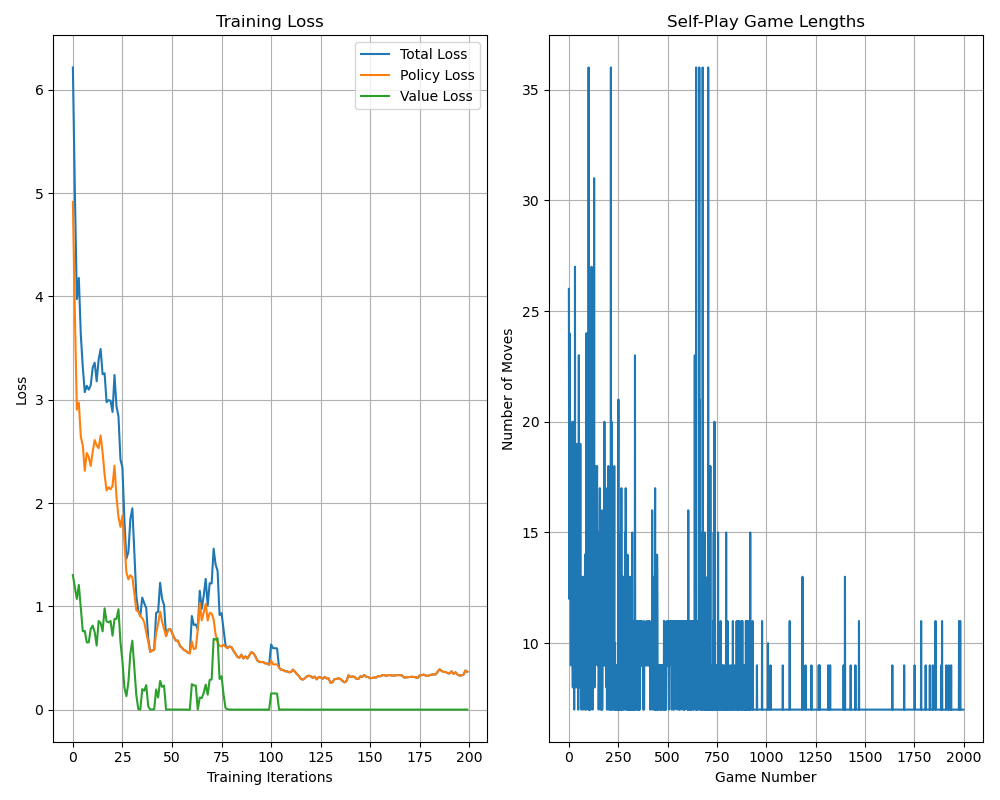

In [50]:
game_size = (6, 6)
game_N = 4

policy = AlphaZeroPolicy(board_size=game_size, num_res_blocks=1, num_channels=32)
trainer = AlphaZeroTrainer(
    game_class=ConnectN,
    game_args={'size': game_size, 'N': game_N},
    policy_model=policy,
    lr=0.01,
    mcts_sims=500,
    batch_size=64,
    buffer_size=256
)

trainer.run(iterations=200, self_play_games=10, sample_size=256, training_epochs=1)

Let's get started! 🚀

Loaded model from models/model_iter_final.pt


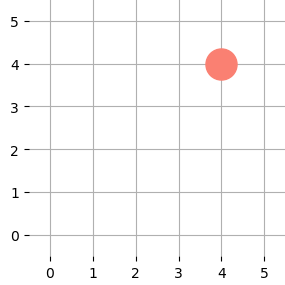

In [55]:
%matplotlib widget 

import random 

def run_mcts(game, policy_network, num_simulations: int = 800, 
             temperature: float = 1.0) -> Tuple[Any, Dict]:
    """
    Run MCTS on the given game state
    
    Args:
        game: The current game state
        policy_network: Neural network for policy and value
        num_simulations: Number of simulations to run
        temperature: Temperature for move selection
        
    Returns:
        Tuple: (selected move, move probabilities)
    """
    root = MCTSNode(game)
    root.search(policy_network, num_simulations)
    return root.get_best_move(temperature) 

def load_model(model_path, game):
    """Load the AI model"""

    data = torch.load(model_path, weights_only=False)
    
    board_size = data['board_size']
    num_res_blocks = data['res_blocks']
    num_channels = data['channels']
    
    model = AlphaZeroPolicy(board_size=board_size, num_res_blocks=num_res_blocks, num_channels=num_channels)
    model.load_state_dict(data['state_dict'])
    print(f"Loaded model from {model_path}")
    
    # Set model to evaluation mode
    model.eval()
    
    return model

def create_ai_player(model, sims=100):
    """Create an AI player function using MCTS"""
    def ai_player(game):
        move, _ = run_mcts(game, model, sims, temperature=0.1)
        return move
    return ai_player

def random_player(game):
    """Create a random player for testing"""
    moves = game.available_moves()
    return random.choice(moves) if moves else None

game = ConnectN(size=(6, 6), N=4)
model_path = "models/model_iter_final.pt"
model = load_model(model_path, game)
ai_player = create_ai_player(model, sims=500)
play = Play(game, player1=ai_player, player2=None)